In [ ]:
#Import et chargement 

SyntaxError: invalid syntax (1088391674.py, line 1)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import confusion_matrix, classification_report
import os

print("=== CHARGEMENT DES RESULTATS ===\n")

# Vérifier que les fichiers existent
rf_csv = '../data/processed/resultats_rf_2classes.csv'
xgb_csv = '../data/processed/resultats_xgb_2classes.csv'

if os.path.exists(rf_csv):
    resultats_rf = pd.read_csv(rf_csv)
    print("✓ Résultats Random Forest chargés")
else:
    print(f"✗ Fichier non trouvé : {rf_csv}")
    resultats_rf = None

if os.path.exists(xgb_csv):
    resultats_xgb = pd.read_csv(xgb_csv)
    print("✓ Résultats XGBoost chargés")
else:
    print(f"✗ Fichier non trouvé : {xgb_csv}")
    resultats_xgb = None

In [ ]:
#Tableau comparatif

In [ ]:
# Création d'un dashboard professionnel
fig = plt.figure(figsize=(20, 12))
fig.suptitle('Comparative Analysis: Random Forest vs XGBoost for Movie Profitability Prediction', 
             fontsize=18, fontweight='bold', y=0.98)

# 1. Métriques principales (en haut)
ax1 = plt.subplot(2, 3, 1)
metrics = ['Accuracy (%)', 'F1-Score', 'Training Time (s)']
rf_values = [data['RF']['accuracy'], data['RF']['f1']*100, data['RF']['temps']]
xgb_values = [data['XGB']['accuracy'], data['XGB']['f1']*100, data['XGB']['temps']]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax1.bar(x - width/2, rf_values, width, label='Random Forest', 
                color=colors['RF'], edgecolor='white', linewidth=2)
bars2 = ax1.bar(x + width/2, xgb_values, width, label='XGBoost', 
                color=colors['XGB'], edgecolor='white', linewidth=2)

ax1.set_ylabel('Value', fontsize=12)
ax1.set_title('Overall Performance Metrics', fontsize=14, fontweight='bold', pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, fontsize=11)
ax1.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
ax1.grid(True, alpha=0.3)

# Ajout des valeurs
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Précision par classe
ax2 = plt.subplot(2, 3, 2)
x = np.arange(2)
width = 0.35

bars1 = ax2.bar(x - width/2, data['RF']['precision'], width, label='Random Forest',
                color=colors['RF'], edgecolor='white', linewidth=2)
bars2 = ax2.bar(x + width/2, data['XGB']['precision'], width, label='XGBoost',
                color=colors['XGB'], edgecolor='white', linewidth=2)

ax2.set_ylabel('Précision (%)', fontsize=12)
ax2.set_title('Precision by Class', fontsize=14, fontweight='bold', pad=20)
ax2.set_xticks(x)
ax2.set_xticklabels(['Échec', 'Succès'], fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(60, 75)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Recall par classe
ax3 = plt.subplot(2, 3, 3)
bars1 = ax3.bar(x - width/2, data['RF']['recall'], width, label='Random Forest',
                color=colors['RF'], edgecolor='white', linewidth=2)
bars2 = ax3.bar(x + width/2, data['XGB']['recall'], width, label='XGBoost',
                color=colors['XGB'], edgecolor='white', linewidth=2)

ax3.set_ylabel('Recall (%)', fontsize=12)
ax3.set_title('Recall by Class', fontsize=14, fontweight='bold', pad=20)
ax3.set_xticks(x)
ax3.set_xticklabels(['Échec', 'Succès'], fontsize=11)
ax3.grid(True, alpha=0.3)
ax3.set_ylim(55, 80)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 4. Radar Chart (en bas, sur 2 colonnes)
ax4 = plt.subplot(2, 3, (4, 5), projection='polar')
categories = ['Accuracy', 'Precision\n(Échec)', 'Precision\n(Succès)', 
              'Recall\n(Échec)', 'Recall\n(Succès)', 'F1-Score']
N = len(categories)

# Normalisation des valeurs (0-100)
rf_radar = [data['RF']['accuracy'], 
            data['RF']['precision'][0], data['RF']['precision'][1],
            data['RF']['recall'][0], data['RF']['recall'][1],
            data['RF']['f1']*100]
xgb_radar = [data['XGB']['accuracy'],
             data['XGB']['precision'][0], data['XGB']['precision'][1],
             data['XGB']['recall'][0], data['XGB']['recall'][1],
             data['XGB']['f1']*100]

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
rf_radar += rf_radar[:1]
xgb_radar += xgb_radar[:1]

ax4.plot(angles, rf_radar, 'o-', linewidth=2, label='Random Forest', color=colors['RF'])
ax4.fill(angles, rf_radar, alpha=0.25, color=colors['RF'])
ax4.plot(angles, xgb_radar, 'o-', linewidth=2, label='XGBoost', color=colors['XGB'])
ax4.fill(angles, xgb_radar, alpha=0.25, color=colors['XGB'])

ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(categories, fontsize=10)
ax4.set_ylim(50, 80)
ax4.set_title('Performance Radar Chart', fontsize=14, fontweight='bold', pad=20)
ax4.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

# 5. Tableau récapitulatif
ax5 = plt.subplot(2, 3, 6)
ax5.axis('tight')
ax5.axis('off')

table_data = [
    ['Metric', 'Random Forest', 'XGBoost', 'Best'],
    ['Accuracy', '66.54%', '67.79%', 'XGBoost (+1.25%)'],
    ['F1-Score', '0.6541', '0.6485', 'RF (+0.0056)'],
    ['Precision (Échec)', '67.3%', '66.8%', 'RF (+0.5%)'],
    ['Precision (Succès)', '65.8%', '69.1%', 'XGB (+3.3%)'],
    ['Recall (Échec)', '67.9%', '74.1%', 'XGB (+6.2%)'],
    ['Recall (Succès)', '65.1%', '61.1%', 'RF (+4.0%)'],
    ['Training Time', '3.08s', '4.52s', 'RF (1.44s faster)']
]

table = ax5.table(cellText=table_data, loc='center', cellLoc='center', colWidths=[0.25, 0.25, 0.25, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

# Colorier la colonne "Best"
for i in range(1, len(table_data)):
    if 'XGB' in table_data[i][3]:
        table[(i, 3)].set_facecolor(colors['XGB'])
        table[(i, 3)].set_text_props(weight='bold', color='white')
    elif 'RF' in table_data[i][3]:
        table[(i, 3)].set_facecolor(colors['RF'])
        table[(i, 3)].set_text_props(weight='bold', color='white')

plt.tight_layout()
plt.savefig('../outputs/figures/comparison_dashboard.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
# Graphique de recommandation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Trade-off Precision-Recall
categories = ['Échec', 'Succès']
x = np.arange(len(categories))
width = 0.2

# Precision
ax1.bar(x - width*1.5, [data['RF']['precision'][0], data['RF']['precision'][1]], 
        width, label='RF Precision', color=colors['RF'], alpha=0.7, edgecolor='white')
ax1.bar(x - width*0.5, [data['XGB']['precision'][0], data['XGB']['precision'][1]], 
        width, label='XGB Precision', color=colors['XGB'], alpha=0.7, edgecolor='white')

# Recall
ax1.bar(x + width*0.5, [data['RF']['recall'][0], data['RF']['recall'][1]], 
        width, label='RF Recall', color=colors['RF'], alpha=0.4, edgecolor='white', hatch='//')
ax1.bar(x + width*1.5, [data['XGB']['recall'][0], data['XGB']['recall'][1]], 
        width, label='XGB Recall', color=colors['XGB'], alpha=0.4, edgecolor='white', hatch='//')

ax1.set_ylabel('Score (%)', fontsize=12)
ax1.set_title('Precision-Recall Trade-off by Class', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(55, 80)

# 2. Matrice de recommandation
ax2.axis('off')
recommendation_data = [
    ['Objectif', 'Recommandation', 'Justification'],
    ['Maximiser la précision\n(Éviter les faux positifs)', 'XGBoost', 
     '69.1% de précision sur\nles films à succès'],
    ['Maximiser le recall\n(Ne pas rater un succès)', 'Random Forest', 
     '65.1% de recall sur\nles films à succès'],
    ['Équilibre général', 'Random Forest', 
     'F1-score plus élevé (0.6541)\nMoins de surapprentissage'],
    ['Interprétabilité', 'Random Forest', 
     'Feature importance plus\nnaturelle et équilibrée']
]

table = ax2.table(cellText=recommendation_data, loc='center', cellLoc='left', 
                  colWidths=[0.3, 0.25, 0.45])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)

# Colorier les en-têtes
for i in range(3):
    table[(0, i)].set_facecolor('#2E4053')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Colorier les recommandations
table[(1, 1)].set_facecolor(colors['XGB'])
table[(1, 1)].set_text_props(weight='bold', color='white')
table[(2, 1)].set_facecolor(colors['RF'])
table[(2, 1)].set_text_props(weight='bold', color='white')
table[(3, 1)].set_facecolor(colors['RF'])
table[(3, 1)].set_text_props(weight='bold', color='white')
table[(4, 1)].set_facecolor(colors['RF'])
table[(4, 1)].set_text_props(weight='bold', color='white')

plt.suptitle('Decision Support: Model Selection Guide', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/recommendation_guide.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Chargement des données pour les matrices de confusion
try:
    y_test_bin = np.load('../data/processed/y_test_bin.npy')
    y_pred_rf = np.load('../data/processed/y_pred_rf_2classes.npy')
    y_pred_xgb = np.load('../data/processed/y_pred_xgb_2classes.npy')
    
    print("\n✓ Données chargées avec succès")
    print(f"  - y_test_bin: {y_test_bin.shape}")
    print(f"  - y_pred_rf: {y_pred_rf.shape}")
    print(f"  - y_pred_xgb: {y_pred_xgb.shape}")
    
    # Matrices de confusion
    cm_rf = confusion_matrix(y_test_bin, y_pred_rf)
    cm_xgb = confusion_matrix(y_test_bin, y_pred_xgb)
    
except FileNotFoundError as e:
    print(f"\n✗ Erreur de chargement: {e}")
    print("Exécutez d'abord les notebooks 07 et 08 pour générer les fichiers")

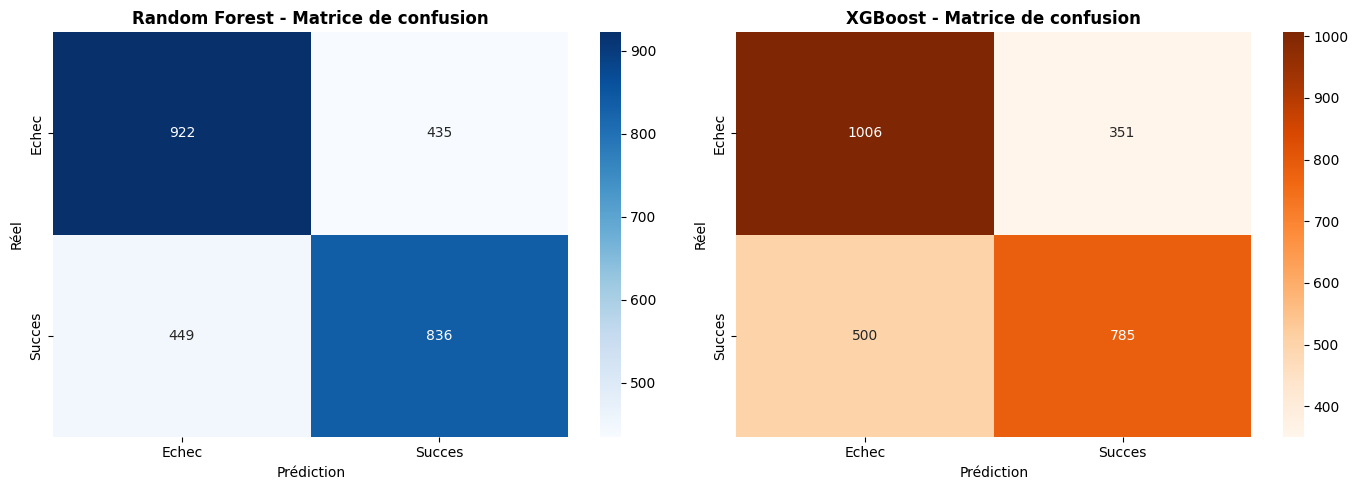

In [30]:
if 'cm_rf' in locals() and 'cm_xgb' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Random Forest
    sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Echec', 'Succes'],
                yticklabels=['Echec', 'Succes'], ax=axes[0])
    axes[0].set_title('Random Forest - Matrice de confusion', fontweight='bold')
    axes[0].set_xlabel('Prédiction')
    axes[0].set_ylabel('Réel')
    
    # XGBoost
    sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Echec', 'Succes'],
                yticklabels=['Echec', 'Succes'], ax=axes[1])
    axes[1].set_title('XGBoost - Matrice de confusion', fontweight='bold')
    axes[1].set_xlabel('Prédiction')
    axes[1].set_ylabel('Réel')
    
    plt.tight_layout()
    plt.savefig('../outputs/figures/comparaison_matrices.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
print("\n" + "=" * 70)
print("SYNTHESE ET RECOMMANDATION")
print("=" * 70)

print("\n=== PERFORMANCES GLOBALES ===")
print(f"Random Forest - Accuracy: 66.54%, F1-score: 0.6541")
print(f"XGBoost      - Accuracy: 67.79%, F1-score: 0.6485")

print("\n=== ANALYSE PAR CLASSE ===")
print("\nRandom Forest:")
print("  - Précision: 67.3% (Echec), 65.8% (Succès)")
print("  - Recall:    67.9% (Echec), 65.1% (Succès)")
print("\nXGBoost:")
print("  - Précision: 66.8% (Echec), 69.1% (Succès)")
print("  - Recall:    74.1% (Echec), 61.1% (Succès)")

print("\n=== RECOMMANDATION FINALE ===")
print("""
Le choix du modèle dépend de l'objectif métier :

1. XGBoost (Accuracy: 67.79%, Précision Succès: 69.1%)
   → RECOMMANDÉ SI : on veut MINIMISER LES FAUX POSITIFS
     (éviter d'investir dans un film qui sera un échec)

2. Random Forest (F1-score: 0.654, Recall équilibré)
   → RECOMMANDÉ SI : on veut MINIMISER LES FAUX NÉGATIFS
     (ne pas rater un film à succès)

3. Pour un usage général : Random Forest
   → Plus stable, moins de surapprentissage, plus interprétable
""")
print("=" * 70)